# Netflix Data Cleaning & Visualization Project
## Project Overview

This project focuses on cleaning, preprocessing, and analyzing the Netflix Movies and TV Shows dataset using Python. The workflow includes data cleaning, feature engineering, exploratory data analysis (EDA), and visualization to extract meaningful business insights.

### Tools & Libraries
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Dataset
Netflix Movies and TV Shows Dataset (Kaggle)

### Objectives
- Perform data cleaning and preprocessing
- Handle missing values and duplicates
- Engineer useful features
- Visualize trends and patterns
- Generate business insights


In [84]:
# Import Required Libraries

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [9]:
# Graph Settings

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

plt.rcParams["figure.dpi"] = 120

In [10]:
#Display Settings

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 100)

pd.set_option("display.max_colwidth", None)

In [129]:
df = pd.read_csv("C:/Users/vivek/OneDrive/Desktop/Netflix-Data-Cleaning-Visualization/data/netflix_titles.csv")

In [130]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


In [13]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey Jr., Anthony Edwards, Brian Cox, Elias Koteas, Donal Logue, John Carroll Lynch, Dermot Mulroney, Chloë Sevigny",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a pair of cops investigate San Francisco's infamous Zodiac Killer in this thriller based on a true story."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young girl befriends a motley crew of zombie children with diverse personalities."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies","Looking to survive in a world taken over by zombies, a dorky college student teams with an urban roughneck and a pair of grifter sisters."
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero must train a new crop of youthful saviors when the military preps for an attack by a familiar villain."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna Malik, Malkeet Rauni, Anita Shabdish, Chittaranjan Tripathy",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals","A scrappy but poor boy worms his way into a tycoon's dysfunctional family, while facing his fear of music and the truth about his past."


In [14]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7351,s7352,Movie,Love Station,Ahmad Samir Farag,"Menna Shalaby, Sherif Salama, Yousra El Lozy, Mona Hala, Edward Fouad, Lotfy Labib, Ashraf Hamdy",Egypt,"April 25, 2019",2011,TV-14,97 min,"Comedies, International Movies, Romantic Movies","Single coworkers at a radio station are brought together by mutual friends, but their starry-eyed notions about love may scuttle their romance."
5487,s5488,Movie,Wild Oats,Andy Tennant,"Shirley MacLaine, Jessica Lange, Billy Connolly, Santiago Segura, Howard Hesseman, Matt Walsh, Jay Hayden, Rebecca Da Costa, Demi Moore","Germany, United States","May 13, 2017",2016,PG-13,86 min,Comedies,"When insurance accidentally pays her millions, retired teacher Eva and her pal Maddie head to the Canary Islands for the adventure of their lives."
4408,s4409,TV Show,Westside,NaN,NaN,United States,"November 9, 2018",2018,TV-MA,1 Season,Reality TV,Nine struggling musicians share the spotlight in this deeply personal reality series about the challenges and thrills of staging a Hollywood showcase.
2828,s2829,Movie,Carmen Sandiego: To Steal or Not to Steal,Jos Humphrey,"Gina Rodriguez, Finn Wolfhard, Abby Trott, Michael Hawley, Liam O'Brien, Mary Elizabeth McGlynn, Toks Olagundoye, Sharon Muthu","Canada, United States","March 10, 2020",2020,TV-Y7,82 min,Children & Family Movies,"You drive the action in this interactive adventure, helping Carmen save Ivy and Zack when V.I.L.E. captures them during a heist in Shanghai."
7342,s7343,TV Show,Lost Girl,NaN,"Anna Silk, Kris Holden-Ried, Ksenia Solo, Richard Howland, Zoie Palmer, K.C. Collins",Canada,"April 17, 2016",2015,TV-14,5 Seasons,"TV Dramas, TV Horror, TV Mysteries","Discovering she's a succubus who sustains herself by feeding on the sexual energy of humans, seductive Bo sets out on a journey to understand herself."


In [15]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 8807
Columns : 12


In [16]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [18]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [19]:
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [20]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [21]:
# Missing values count
missing = df.isnull().sum().sort_values(ascending=False)

print("Missing Values:")
print(missing)

Missing Values:
director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64


In [22]:
# Missing values percentage
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("\nMissing Values Percentage:")
print(missing_percent)


Missing Values Percentage:
director        29.908028
country          9.435676
cast             9.367549
date_added       0.113546
rating           0.045418
duration         0.034064
show_id          0.000000
type             0.000000
title            0.000000
release_year     0.000000
listed_in        0.000000
description      0.000000
dtype: float64


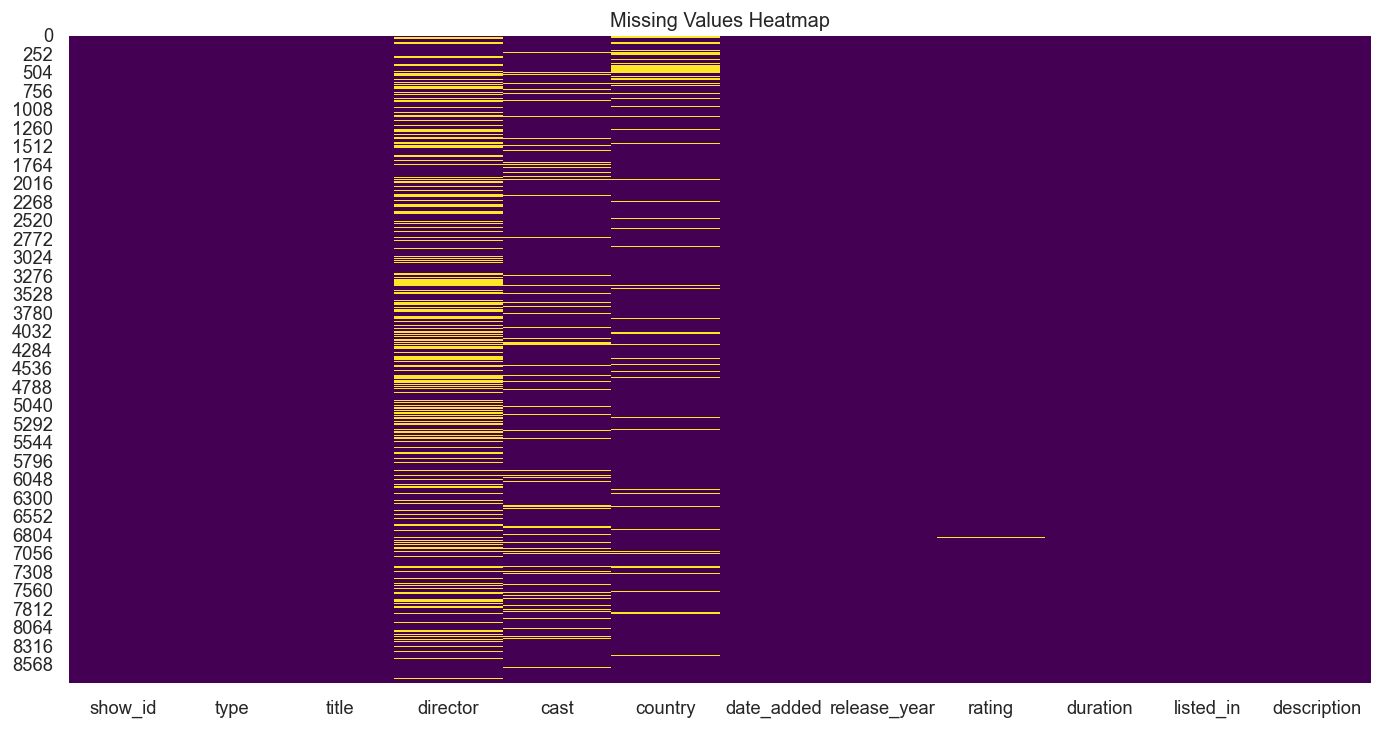

In [23]:
#Visualising Missing Values
plt.figure(figsize=(14,7))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
columns = ["type", "rating", "country", "listed_in"]

for col in columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(f"Unique Values ({df[col].nunique()}):")
    print(df[col].unique())
    print()

print("Total Unique Values in Each Column:")
print(df.nunique())

Column: type
Unique Values (2):
['Movie' 'TV Show']

Column: rating
Unique Values (17):
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']

Column: country
Unique Values (748):
['United States' 'South Africa' nan 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia'
 'United States, India, France' 'Finland' 'China, Canada, United States'
 'South Africa, United States, Japan' 'Nigeria' 'Japan'
 'Spain, United States' 'France' 'Belgium' 'United Kingdom, United States'
 'United States, United Kingdom' 'France, United States' 'South Korea'
 'Spain' 'United States, Singapore' 'United Kingdom, Australia, France'
 'United Kingdom, Australia, France, United States'
 'United States, Canada' 'Germany, United States'
 'South Africa, United States' 'United States, Mexico'
 'United States, Italy, France, Japan'
 'United S

In [26]:
df.memory_usage(deep=True)
df.memory_usage(deep=True).sum()/1024**2

np.float64(7.981891632080078)

In [27]:
# Total memory usage in MB
df.memory_usage(deep=True).sum() / 1024**2

np.float64(7.981891632080078)

In [28]:
#Displaying Random Titles
df[["title","type","country"]].sample(10)

,title,type,country
3127,Cinderella and the Four Knights,TV Show,South Korea
2599,El señor de los Cielos,TV Show,"United States, Mexico, Colombia"
7011,"Houston, We Have a Problem!",Movie,"Slovenia, Croatia, Germany, Czech Republic, Qatar"
6634,Doom,Movie,"United Kingdom, Czech Republic, Germany, United States"
2213,The Kissing Booth 2,Movie,"United Kingdom, United States"
6706,Estar o no estar,Movie,Mexico
5830,Rebirth,Movie,United States
178,The Interview,Movie,United States
1861,Dil,Movie,India
161,Mars Attacks!,Movie,United States


In [29]:
## Initial Observations
"""
- Dataset contains approximately 8,800 Netflix titles.
- There are 12 features including movie metadata such as director, cast, country, rating, duration, and release year.
- Several columns contain missing values (director, cast, country, date_added, rating).
- The dataset includes both Movies and TV Shows.
- Most columns are categorical.
- The date_added column needs conversion to datetime format.
- Duplicate records (if any) will be removed during preprocessing.
"""

'\n- Dataset contains approximately 8,800 Netflix titles.\n- There are 12 features including movie metadata such as director, cast, country, rating, duration, and release year.\n- Several columns contain missing values (director, cast, country, date_added, rating).\n- The dataset includes both Movies and TV Shows.\n- Most columns are categorical.\n- The date_added column needs conversion to datetime format.\n- Duplicate records (if any) will be removed during preprocessing.\n'

In [30]:
df_original = df.copy()

----------------------------------------------------------------------------------------------------------------------------------------------

# Chapter 2: Data Cleaning & Feature Engineering
"""
 Objective
The objective of this chapter is to clean the Netflix dataset by handling missing values, removing inconsistencies, converting data types, and creating meaningful features for further analysis. A clean dataset ensures accurate and reliable exploratory data analysis (EDA) and visualization.
"""

In [35]:
# Create a separate copy of the dataset for cleaning

netflix_df = df.copy()

print("Working copy created successfully.")
print(f"Dataset Shape : {netflix_df.shape}")

Working copy created successfully.
Dataset Shape : (8807, 12)


In [36]:
# Check missing values before cleaning

print("Checking missing values...\n")

missing_data = pd.DataFrame({
    "Missing Values": netflix_df.isnull().sum(),
    "Percentage (%)": ((netflix_df.isnull().sum() / len(netflix_df)) * 100).round(2)
})

missing_data = missing_data[missing_data["Missing Values"] > 0]

missing_data = missing_data.sort_values(
    by="Missing Values",
    ascending=False
)

missing_data

Checking missing values...



,Missing Values,Percentage (%)
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


### Observation

The dataset contains missing values in the following columns:

- Director
- Cast
- Country
- Date Added
- Rating

Instead of deleting the entire records, appropriate techniques will be applied to preserve maximum information.

In [37]:
# Replace missing director names with "Unknown"

netflix_df["director"] = netflix_df["director"].fillna("Unknown")

print("Missing values in Director column handled successfully.")

Missing values in Director column handled successfully.


In [38]:
# Verifying
print("Remaining Missing Values :", netflix_df["director"].isnull().sum())

Remaining Missing Values : 0


In [39]:
# Replace missing cast information

netflix_df["cast"] = netflix_df["cast"].fillna("Not Available")

print("Missing values in Cast column handled successfully.")

Missing values in Cast column handled successfully.


In [40]:
# Verifying
print("Remaining Missing Values :", netflix_df["cast"].isnull().sum())

Remaining Missing Values : 0


In [41]:
# Find the most frequent country

country_mode = netflix_df["country"].mode()[0]

print(f"Most Frequent Country : {country_mode}")

Most Frequent Country : United States


In [42]:
netflix_df["country"] = netflix_df["country"].fillna(country_mode)

print("Missing values in Country column handled successfully.")

Missing values in Country column handled successfully.


In [43]:
# Verifying
print("Remaining Missing Values :", netflix_df["country"].isnull().sum())

Remaining Missing Values : 0


In [44]:
# Find the most frequent rating

rating_mode = netflix_df["rating"].mode()[0]

print(f"Most Frequent Rating : {rating_mode}")

Most Frequent Rating : TV-MA


In [45]:
netflix_df["rating"] = netflix_df["rating"].fillna(rating_mode)

print("Missing values in Rating column handled successfully.")

Missing values in Rating column handled successfully.


In [46]:
# Verifying
print("Remaining Missing Values :", netflix_df["rating"].isnull().sum())


Remaining Missing Values : 0


In [47]:
# Check missing values

print("Missing Date Added Values :",
      netflix_df["date_added"].isnull().sum())

Missing Date Added Values : 10


In [48]:
netflix_df.dropna(subset=["date_added"], inplace=True)

print("Rows with missing Date Added removed successfully.")

Rows with missing Date Added removed successfully.


In [49]:
# Verifying
print("Remaining Missing Values :",
      netflix_df["date_added"].isnull().sum())

Remaining Missing Values : 0


In [50]:
print("Checking missing values after cleaning...\n")

missing_after = pd.DataFrame({
    "Missing Values": netflix_df.isnull().sum(),
    "Percentage (%)": ((netflix_df.isnull().sum()/len(netflix_df))*100).round(2)
})

missing_after

Checking missing values after cleaning...



,Missing Values,Percentage (%)
show_id,0,0.00
type,0,0.00
title,0,0.00
director,0,0.00
cast,0,0.00
country,0,0.00
date_added,0,0.00
release_year,0,0.00
rating,0,0.00
duration,3,0.03


### Observation

All important missing values have been handled successfully.

- Director → Filled with **Unknown**
- Cast → Filled with **Not Available**
- Country → Filled using the most frequent country
- Rating → Filled using the most frequent rating
- Date Added → Missing records removed

In [51]:
duplicate_records = netflix_df.duplicated().sum()

print(f"Duplicate Records Found : {duplicate_records}")

Duplicate Records Found : 0


In [53]:
print("Dataset Shape After Cleaning")

print(f"Rows : {netflix_df.shape[0]}")

print(f"Columns : {netflix_df.shape[1]}")

Dataset Shape After Cleaning
Rows : 8797
Columns : 12


In [58]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war."
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life."


### Observation

The missing values in the dataset have been successfully handled using appropriate preprocessing techniques. Duplicate records were also checked, and no duplicate entries were found in the dataset.

At this stage, the dataset has become cleaner and more consistent. The next step is to perform data type conversion and feature engineering to prepare the dataset for exploratory data analysis.

In [59]:
# Display the current data type of date_added column

print("Current Data Type:")
print(netflix_df["date_added"].dtype)

Current Data Type:
object


In [62]:
# Remove unnecessary spaces

netflix_df["date_added"] = netflix_df["date_added"].str.strip()

# Convert to datetime

netflix_df["date_added"] = pd.to_datetime(
    netflix_df["date_added"],
    errors="coerce"
)

print("date_added column converted successfully.")

date_added column converted successfully.


In [64]:
# Verify the updated data type

print("Updated Data Type:")
print(netflix_df["date_added"].dtype)

Updated Data Type:
datetime64[ns]


### Observation

The `date_added` column was successfully converted from object to datetime format. This enables extraction of useful date-based features such as year, month, and day for further analysis.

In [65]:
# Display sample records before text cleaning

print("Sample data before text standardization:")

netflix_df[["title", "director", "country"]].head()

Sample data before text standardization:


,title,director,country
0,Dick Johnson Is Dead,Kirsten Johnson,United States
1,Blood & Water,Unknown,South Africa
2,Ganglands,Julien Leclercq,United States
3,Jailbirds New Orleans,Unknown,United States
4,Kota Factory,Unknown,India


In [66]:
# Remove leading and trailing spaces from text columns

text_columns = [
    "title",
    "director",
    "cast",
    "country",
    "rating",
    "listed_in"
]

for column in text_columns:
    netflix_df[column] = netflix_df[column].str.strip()

print("Text standardization completed successfully.")

Text standardization completed successfully.


In [67]:
# Display sample records after cleaning

print("Sample data after text standardization:")

netflix_df[["title", "director", "country"]].head()

Sample data after text standardization:


,title,director,country
0,Dick Johnson Is Dead,Kirsten Johnson,United States
1,Blood & Water,Unknown,South Africa
2,Ganglands,Julien Leclercq,United States
3,Jailbirds New Orleans,Unknown,United States
4,Kota Factory,Unknown,India


### Observation

All selected text columns were standardized by removing unnecessary leading and trailing spaces. This ensures consistency in the dataset and prevents issues during filtering, grouping, and visualization.

In [68]:
# Extract year from date_added

netflix_df["year_added"] = netflix_df["date_added"].dt.year

print("Feature 'year_added' created successfully.")

Feature 'year_added' created successfully.


In [69]:
# Extract month name from date_added

netflix_df["month_added"] = netflix_df["date_added"].dt.month_name()

print("Feature 'month_added' created successfully.")

Feature 'month_added' created successfully.


In [70]:
# Extract day name from date_added

netflix_df["day_added"] = netflix_df["date_added"].dt.day_name()

print("Feature 'day_added' created successfully.")

Feature 'day_added' created successfully.


In [71]:
# Display newly created date features

netflix_df[
    [
        "date_added",
        "year_added",
        "month_added",
        "day_added"
    ]
].head()

,date_added,year_added,month_added,day_added
0,2021-09-25,2021,September,Saturday
1,2021-09-24,2021,September,Friday
2,2021-09-24,2021,September,Friday
3,2021-09-24,2021,September,Friday
4,2021-09-24,2021,September,Friday


### Observation

Three new features (`year_added`, `month_added`, and `day_added`) were created from the `date_added` column. These features will be useful for analyzing Netflix content additions over time.

In [72]:
# Extract numeric value from duration column

netflix_df["movie_duration"] = netflix_df["duration"].str.extract(r"(\d+)")

netflix_df["movie_duration"] = pd.to_numeric(
    netflix_df["movie_duration"]
)

print("Numeric duration extracted successfully.")

Numeric duration extracted successfully.


In [73]:
# Extract duration unit (min or Season/Seasons)

netflix_df["duration_unit"] = netflix_df["duration"].str.extract(r"([A-Za-z]+(?:\s?[A-Za-z]+)?)")

print("Duration unit extracted successfully.")

Duration unit extracted successfully.


In [74]:
netflix_df[
    [
        "duration",
        "movie_duration",
        "duration_unit"
    ]
].head(10)

,duration,movie_duration,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
5,1 Season,1.0,Season
6,91 min,91.0,min
7,125 min,125.0,min
8,9 Seasons,9.0,Seasons
9,104 min,104.0,min


### Observation

The `duration` column was split into two separate features: a numeric duration (`movie_duration`) and its corresponding unit (`duration_unit`). This makes duration analysis easier for both movies and TV shows.

In [75]:
# Extract the first listed genre

netflix_df["primary_genre"] = netflix_df["listed_in"].str.split(",").str[0]

print("Primary genre extracted successfully.")

Primary genre extracted successfully.


In [76]:
# Extract the first listed country

netflix_df["primary_country"] = netflix_df["country"].str.split(",").str[0]

print("Primary country extracted successfully.")

Primary country extracted successfully.


In [77]:
netflix_df[
    [
        "listed_in",
        "primary_genre",
        "country",
        "primary_country"
    ]
].head()

,listed_in,primary_genre,country,primary_country
0,Documentaries,Documentaries,United States,United States
1,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows,South Africa,South Africa
2,"Crime TV Shows, International TV Shows, TV Action & Adventure",Crime TV Shows,United States,United States
3,"Docuseries, Reality TV",Docuseries,United States,United States
4,"International TV Shows, Romantic TV Shows, TV Comedies",International TV Shows,India,India


### Observation

The primary genre and primary country were extracted from columns containing multiple values. These simplified features will make categorical analysis and visualizations more straightforward.

In [78]:
# Display dataset information

print("Final Dataset Information:\n")

netflix_df.info()

Final Dataset Information:

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8797 non-null   object        
 1   type             8797 non-null   object        
 2   title            8797 non-null   object        
 3   director         8797 non-null   object        
 4   cast             8797 non-null   object        
 5   country          8797 non-null   object        
 6   date_added       8797 non-null   datetime64[ns]
 7   release_year     8797 non-null   int64         
 8   rating           8797 non-null   object        
 9   duration         8794 non-null   object        
 10  listed_in        8797 non-null   object        
 11  description      8797 non-null   object        
 12  year_added       8797 non-null   int32         
 13  month_added      8797 non-null   object        
 14  day_added        

In [79]:
# Check remaining missing values

print("Remaining Missing Values:\n")

netflix_df.isnull().sum()

Remaining Missing Values:



show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           3
listed_in          0
description        0
year_added         0
month_added        0
day_added          0
movie_duration     3
duration_unit      3
primary_genre      0
primary_country    0
dtype: int64

In [80]:
# Display final dataset shape

print(f"Final Dataset Shape: {netflix_df.shape}")

Final Dataset Shape: (8797, 19)


In [81]:
# Preview cleaned dataset

netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,movie_duration,duration_unit,primary_genre,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.",2021,September,Saturday,90.0,min,Documentaries,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.",2021,September,Friday,2.0,Seasons,International TV Shows,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robbers are pulled into a violent and deadly turf war.",2021,September,Friday,1.0,Season,Crime TV Shows,United States
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice Center in New Orleans on this gritty reality series.",2021,September,Friday,1.0,Season,Docuseries,United States
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Arun Kumar",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.",2021,September,Friday,2.0,Seasons,International TV Shows,India


In [85]:
# Create folder if it doesn't exist

os.makedirs("cleaned_data", exist_ok=True)

# Save cleaned dataset

netflix_df.to_csv(
    "cleaned_data/cleaned_netflix.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [86]:
# Save the cleaned dataset

netflix_df.to_csv(
    "cleaned_data/cleaned_netflix.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


----------------------------------------------------------------------------------------------------------------------------------------------

# Chapter 3: Exploratory Data Analysis (EDA)

## Objective

The objective of this chapter is to explore the cleaned Netflix dataset using descriptive statistics and visualizations. The analysis aims to identify patterns, trends, and relationships within the data, helping generate meaningful business insights.

----------------------------------------------------------------------------------------------------------------------------------------------

## Distribution of Movies and TV Shows

### Objective

This analysis aims to understand the overall composition of Netflix's content library by comparing the number of Movies and TV Shows available on the platform.

In [87]:
# Count Movies and TV Shows

content_type = netflix_df["type"].value_counts()

print("Content Distribution:\n")

print(content_type)

Content Distribution:

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


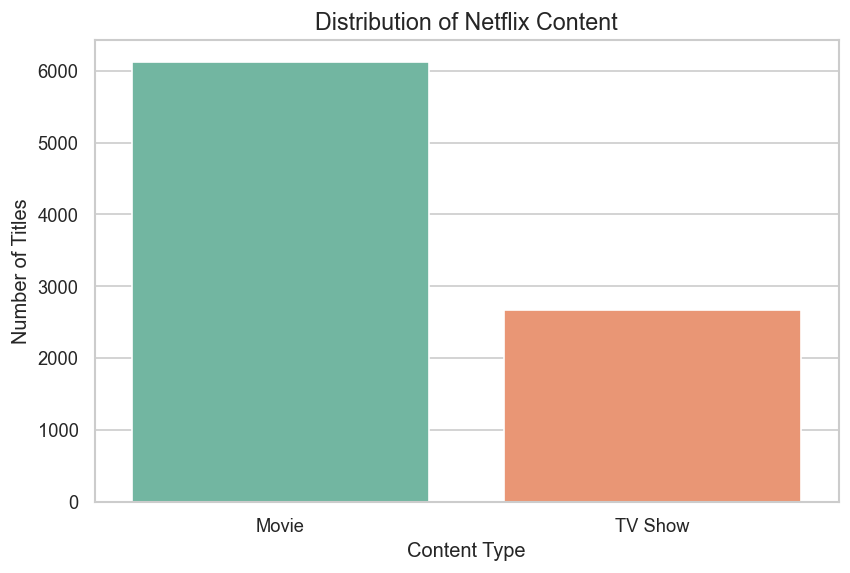

In [88]:
# Create a bar chart for Movies vs TV Shows

plt.figure(figsize=(8,5))

sns.countplot(
    data=netflix_df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Netflix Content", fontsize=14)

plt.xlabel("Content Type")

plt.ylabel("Number of Titles")

plt.show()

In [89]:
# Display percentage distribution

content_percentage = (
    netflix_df["type"]
    .value_counts(normalize=True)
    * 100
).round(2)

print("Percentage Distribution:\n")

print(content_percentage)

Percentage Distribution:

type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


### Key Insights

The dataset contains significantly more **Movies** than **TV Shows**, indicating that Netflix's catalog is dominated by movie content. This suggests that the platform has historically focused more on movies while gradually expanding its TV Show collection.

-------------------------------------------------------------------------------------------------------------------------

##  Content Added Over the Years

### Objective

This analysis examines how Netflix has expanded its content library over time by identifying the number of titles added each year.

In [90]:
# Count titles added each year

content_year = (
    netflix_df["year_added"]
    .value_counts()
    .sort_index()
)

print(content_year)

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64


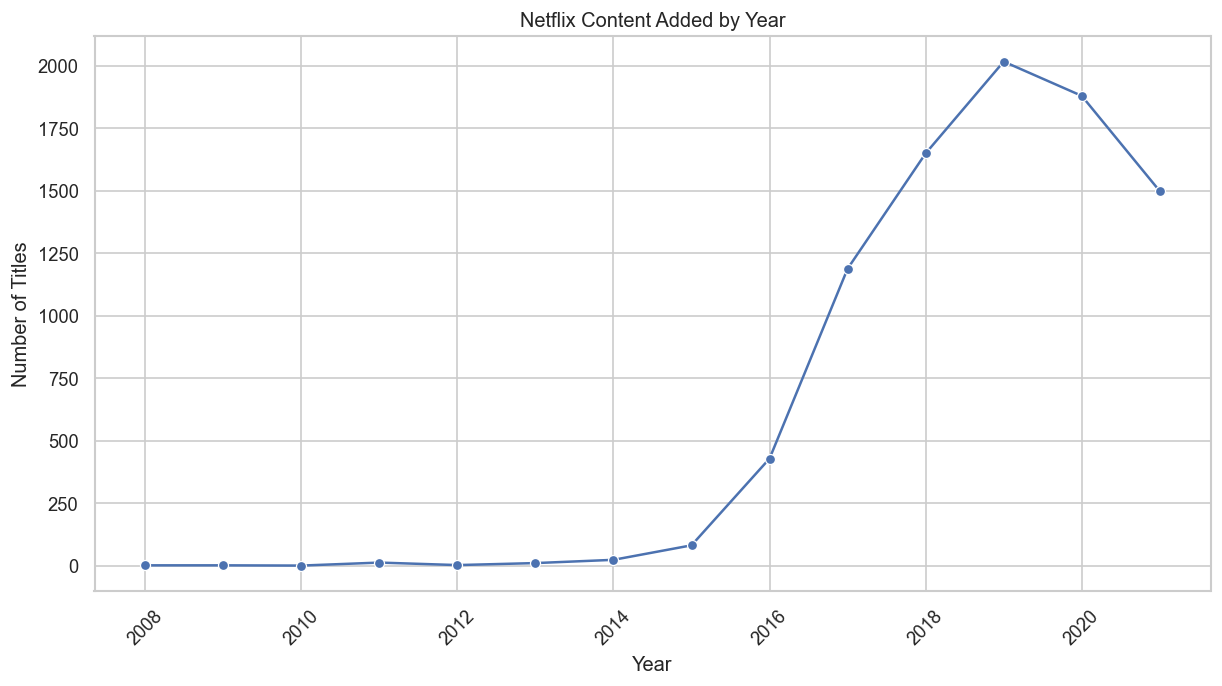

In [91]:
# Plot yearly content additions

plt.figure(figsize=(12,6))

sns.lineplot(
    x=content_year.index,
    y=content_year.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")

plt.xlabel("Year")

plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Key Insights

Netflix experienced a significant increase in content additions after 2015, with rapid growth until around 2019. This reflects the platform's aggressive investment in expanding its global content library during those years.

-------------------------------------------------------------------------------------------------------------------------

## Monthly Content Distribution

### Objective

This analysis identifies the months in which Netflix adds the highest amount of content to its platform.

In [93]:
# Arrange months in calendar order

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_content = (
    netflix_df["month_added"]
    .value_counts()
    .reindex(month_order)
)

print(monthly_content)

month_added
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64


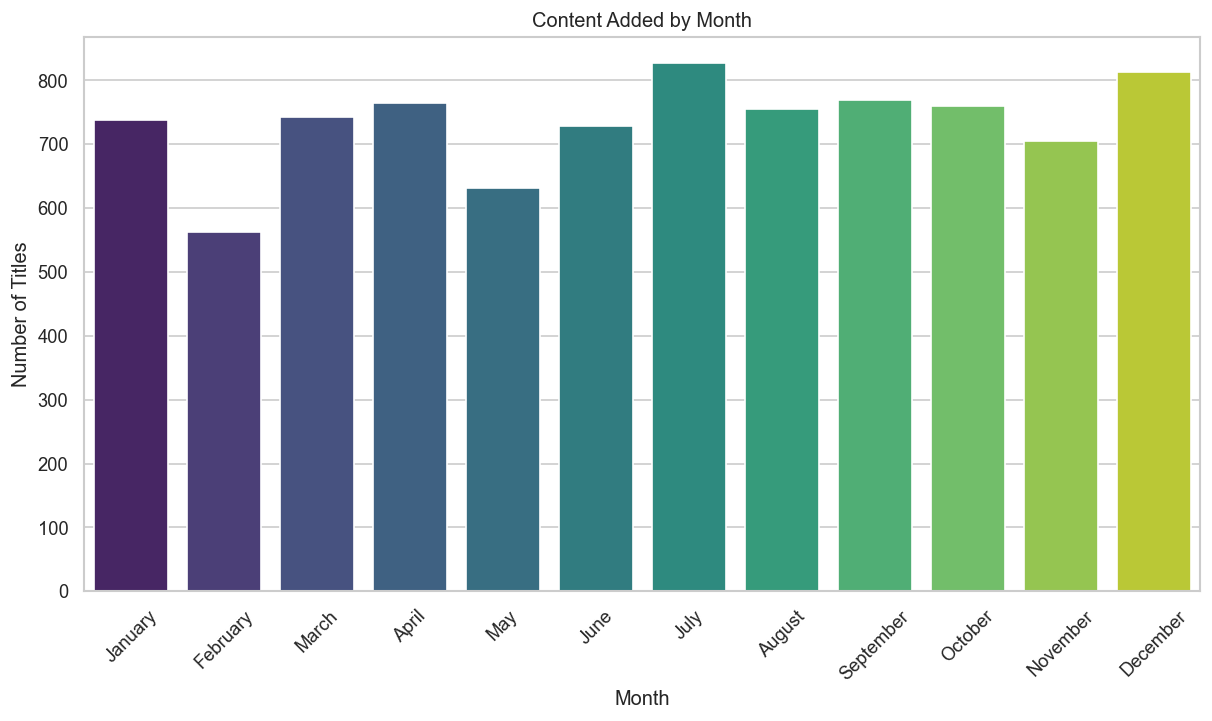

In [94]:
# Plot monthly additions

plt.figure(figsize=(12,6))

sns.barplot(
    x=monthly_content.index,
    y=monthly_content.values,
    hue=monthly_content.index,
    palette="viridis",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Content Added by Month")

plt.xlabel("Month")

plt.ylabel("Number of Titles")

plt.show()

### Key Insights

The number of titles added varies across different months, indicating that Netflix follows seasonal content release patterns rather than maintaining a uniform release schedule throughout the year.

-------------------------------------------------------------------------------------------------------------------------

## Top 10 Countries Producing Netflix Content

### Objective

The objective of this analysis is to identify the countries that contribute the highest number of titles to Netflix's content library.

In [96]:
# Count the number of titles by country

top_countries = (
    netflix_df["primary_country"]
    .value_counts()
    .head(10)
)

print("Top 10 Countries:\n")

print(top_countries)

Top 10 Countries:

primary_country
United States     4035
India             1008
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Australia          116
Name: count, dtype: int64


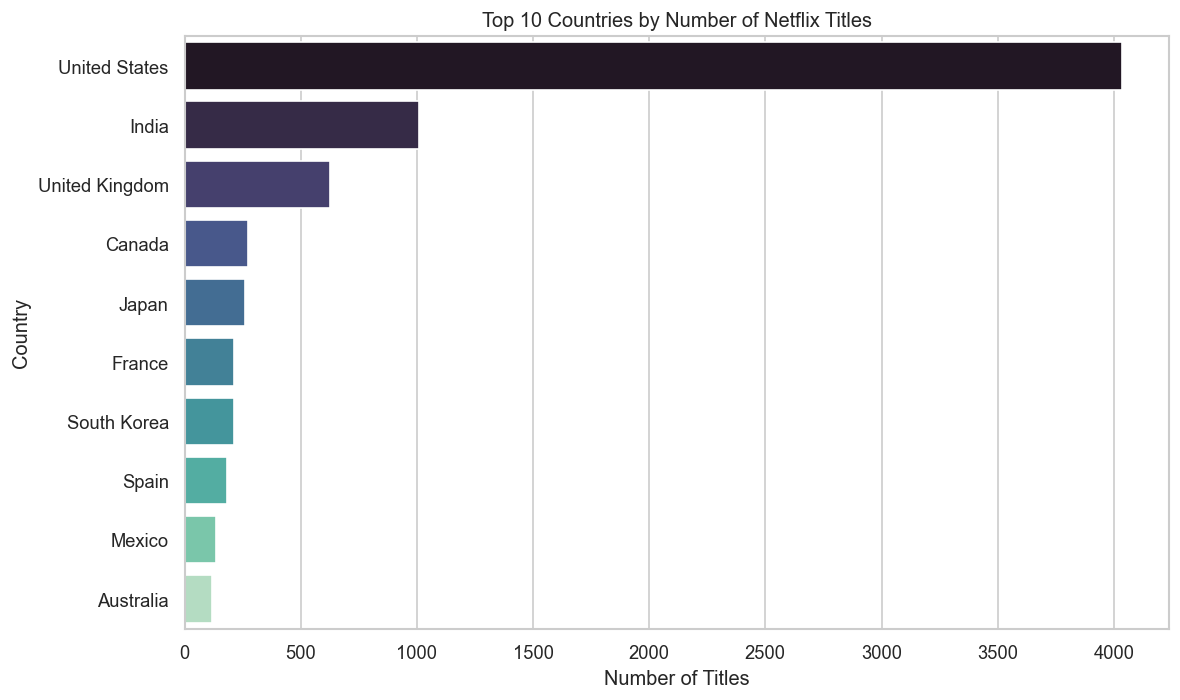

In [97]:
# Plot the top 10 countries

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="mako",
    legend=False
)

plt.title("Top 10 Countries by Number of Netflix Titles")

plt.xlabel("Number of Titles")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

### Key Insight

The United States contributes the highest number of titles in the Netflix catalog, followed by countries such as India and the United Kingdom. This indicates Netflix's strong presence in these entertainment markets.

----------------------------------------------------------------------------------------------------------------------------------------------

## Most Popular Genres on Netflix

### Objective

The objective of this analysis is to identify the genres that appear most frequently in the Netflix catalog.

In [98]:
# Count the frequency of primary genres

top_genres = (
    netflix_df["primary_genre"]
    .value_counts()
    .head(10)
)

print("Top 10 Genres:\n")

print(top_genres)

Top 10 Genres:

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     386
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


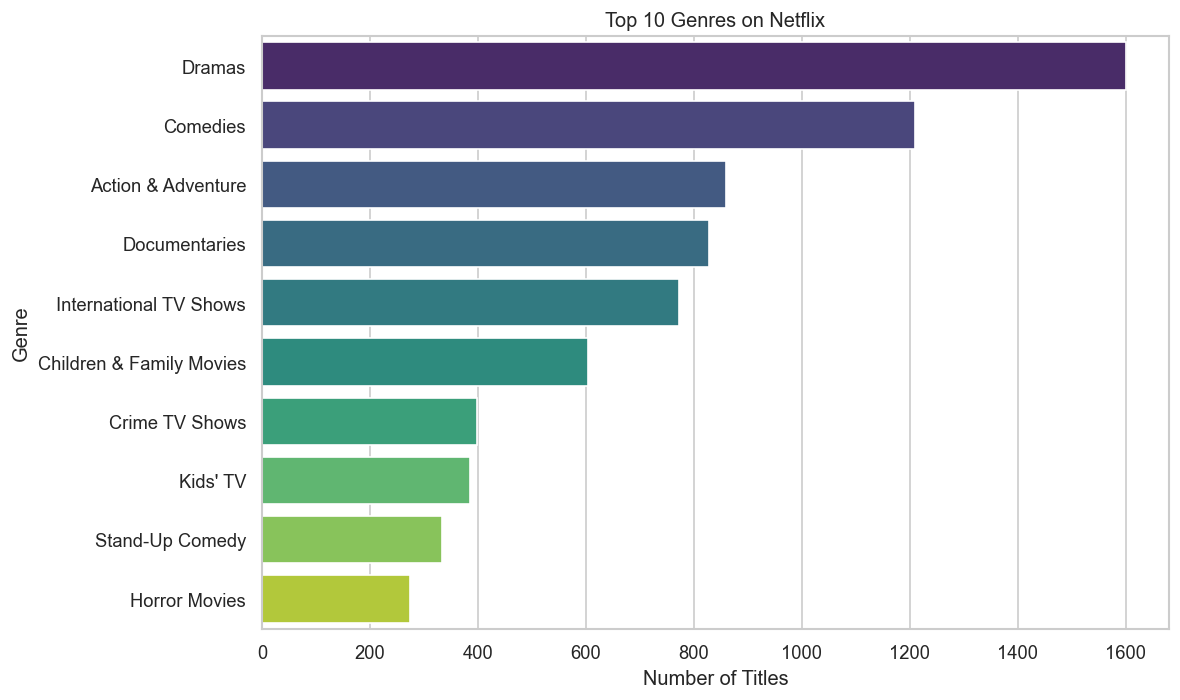

In [99]:
# Plot the top genres

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Genres on Netflix")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")

plt.tight_layout()

plt.show()

### Key Insight

Drama is the most common genre in the Netflix dataset, followed by Comedy and Documentary. This suggests that Netflix offers a diverse collection while maintaining a strong focus on drama-based content.

----------------------------------------------------------------------------------------------------------------------------------------------

## Distribution of Content Ratings

### Objective

The objective of this analysis is to understand the distribution of content ratings available on Netflix.

In [100]:
# Count the number of titles for each content rating

rating_distribution = netflix_df["rating"].value_counts()

print("Content Ratings:\n")

print(rating_distribution)

Content Ratings:

rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


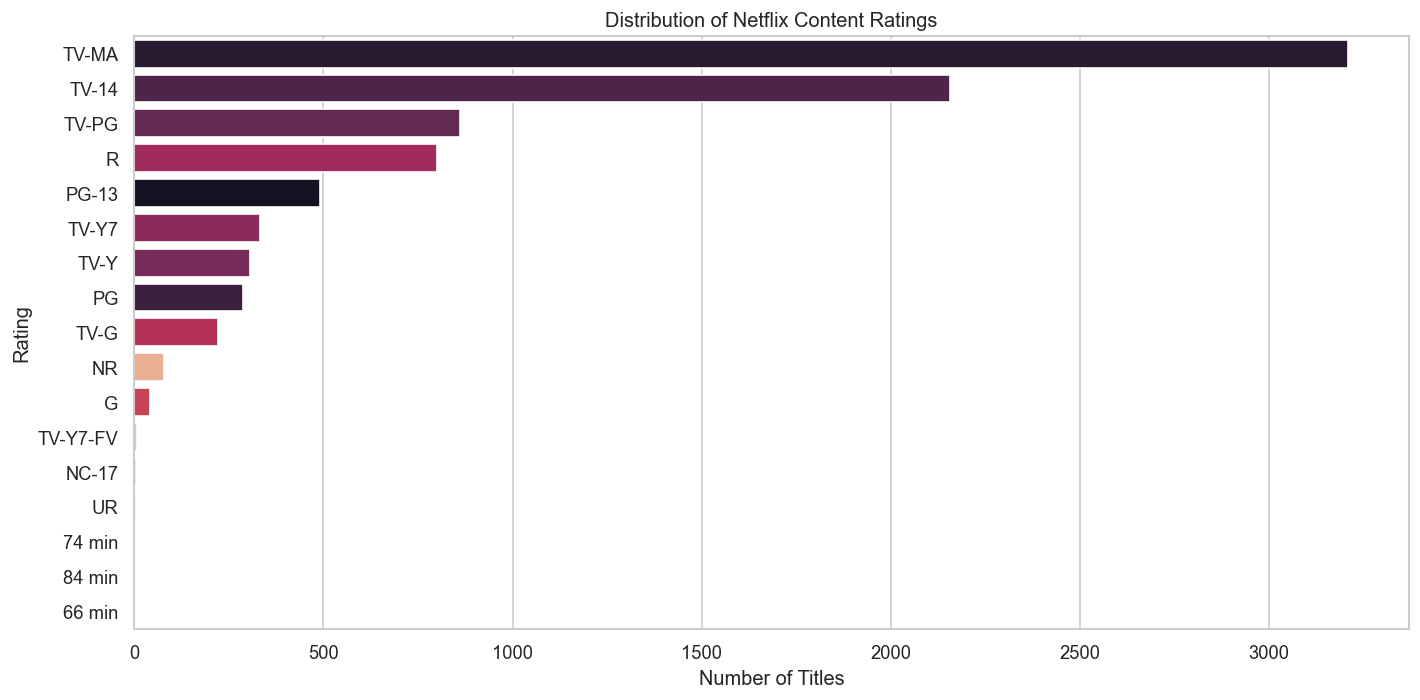

In [101]:
# Plot content rating distribution

plt.figure(figsize=(12,6))

sns.countplot(
    data=netflix_df,
    y="rating",
    order=netflix_df["rating"].value_counts().index,
    hue="rating",
    palette="rocket",
    legend=False
)

plt.title("Distribution of Netflix Content Ratings")

plt.xlabel("Number of Titles")

plt.ylabel("Rating")

plt.tight_layout()

plt.show()

### Key Insight

Most Netflix titles fall under TV-MA and TV-14 ratings, indicating that a large portion of the platform's content is targeted toward mature and teenage audiences.

----------------------------------------------------------------------------------------------------------------------------------------------

## Distribution of Movie Duration

### Objective

The objective of this analysis is to examine the duration of Netflix content and identify common duration ranges.

In [103]:
# Filter only movie records

movies = netflix_df[
    netflix_df["type"] == "Movie"
]

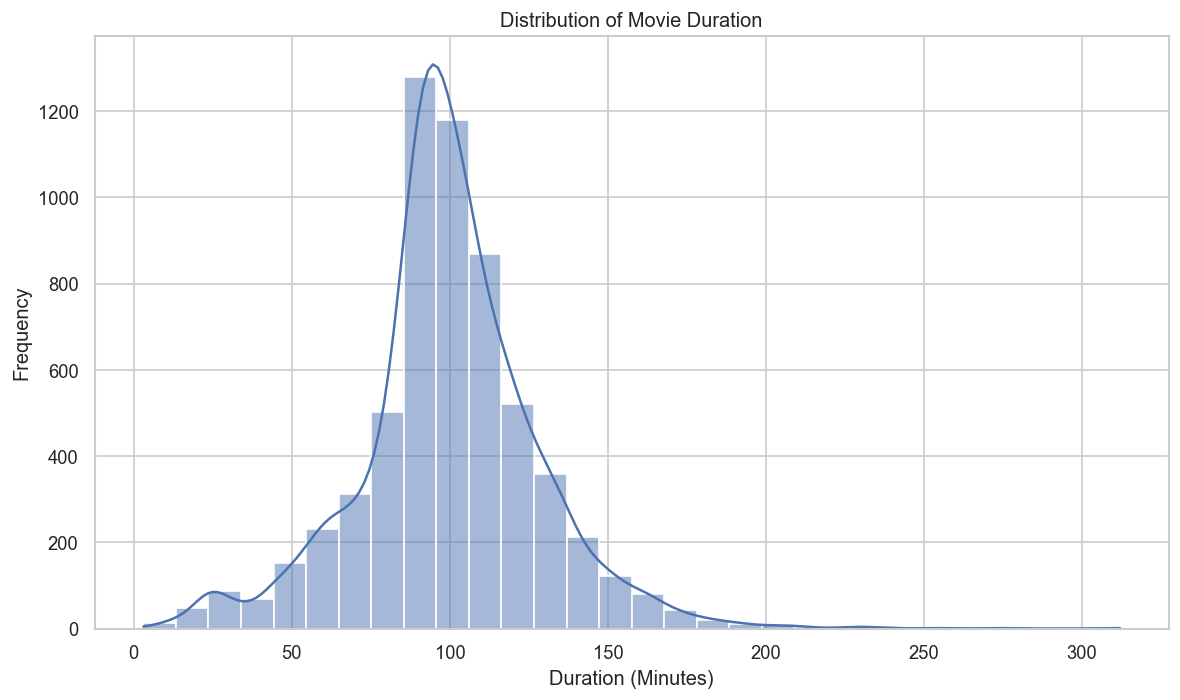

In [104]:
# Plot movie duration distribution

plt.figure(figsize=(10,6))

sns.histplot(
    movies["movie_duration"],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Key Insight

Most Netflix movies have a duration between 80 and 120 minutes, which aligns with the typical runtime of feature-length films.

----------------------------------------------------------------------------------------------------------------------------------------------

## Directors with the Highest Number of Titles

### Objective

The objective of this analysis is to identify the directors who have contributed the most titles to Netflix.

In [106]:
# Exclude unknown directors

top_directors = (
    netflix_df[
        netflix_df["director"] != "Unknown"
    ]["director"]
    .value_counts()
    .head(10)
)

print("Top Directors:\n")

print(top_directors)

Top Directors:

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


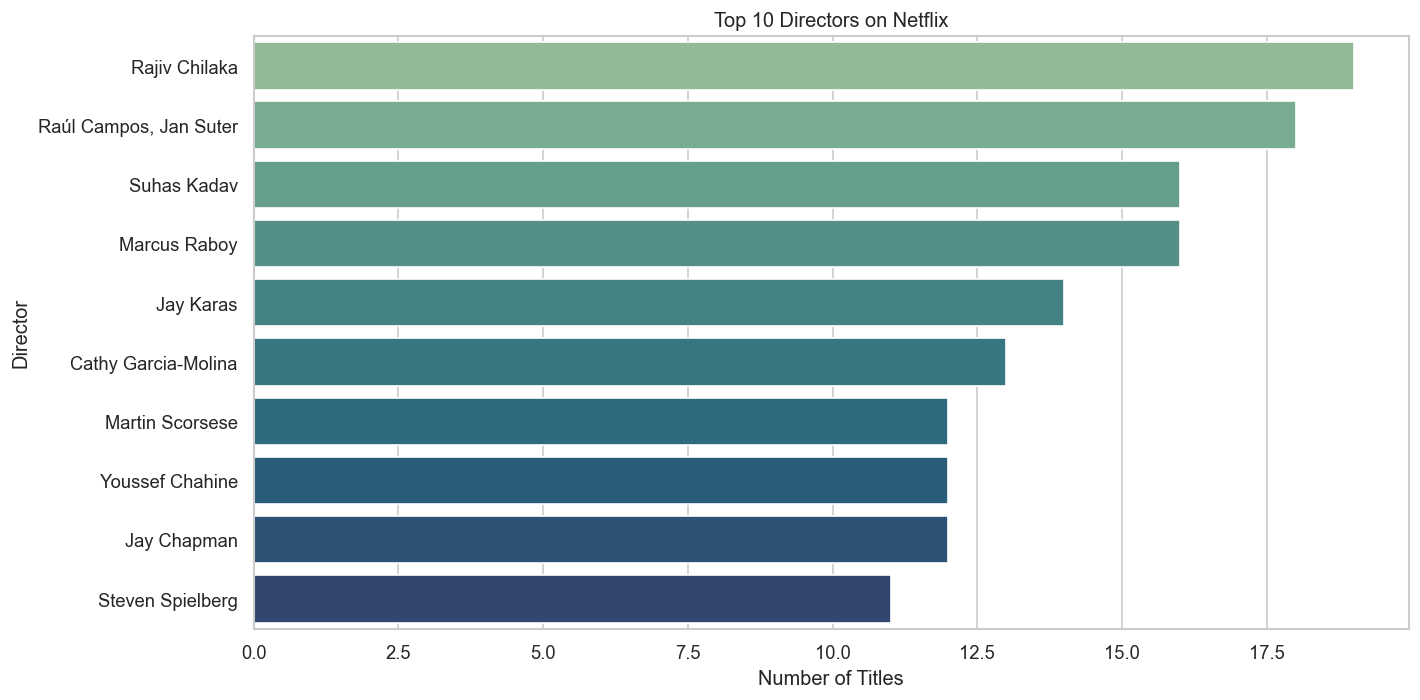

In [107]:
# Plot top directors

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette="crest",
    legend=False
)

plt.title("Top 10 Directors on Netflix")

plt.xlabel("Number of Titles")

plt.ylabel("Director")

plt.tight_layout()

plt.show()

### Key Insight

A small number of directors contribute multiple titles to Netflix, while the majority of directors appear only once or twice. This reflects the diversity of content creators available on the platform.

----------------------------------------------------------------------------------------------------------------------------------------------

##  Content Release Trend

### Objective

The objective of this analysis is to examine how the production of Netflix content has changed over the years based on the release year of Movies and TV Shows.

In [109]:
# Count the number of titles released each year

release_trend = (
    netflix_df["release_year"]
    .value_counts()
    .sort_index()
)

print("Release Year Trend:\n")

print(release_trend.tail(10))

Release Year Trend:

release_year
2012     236
2013     287
2014     352
2015     558
2016     901
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64


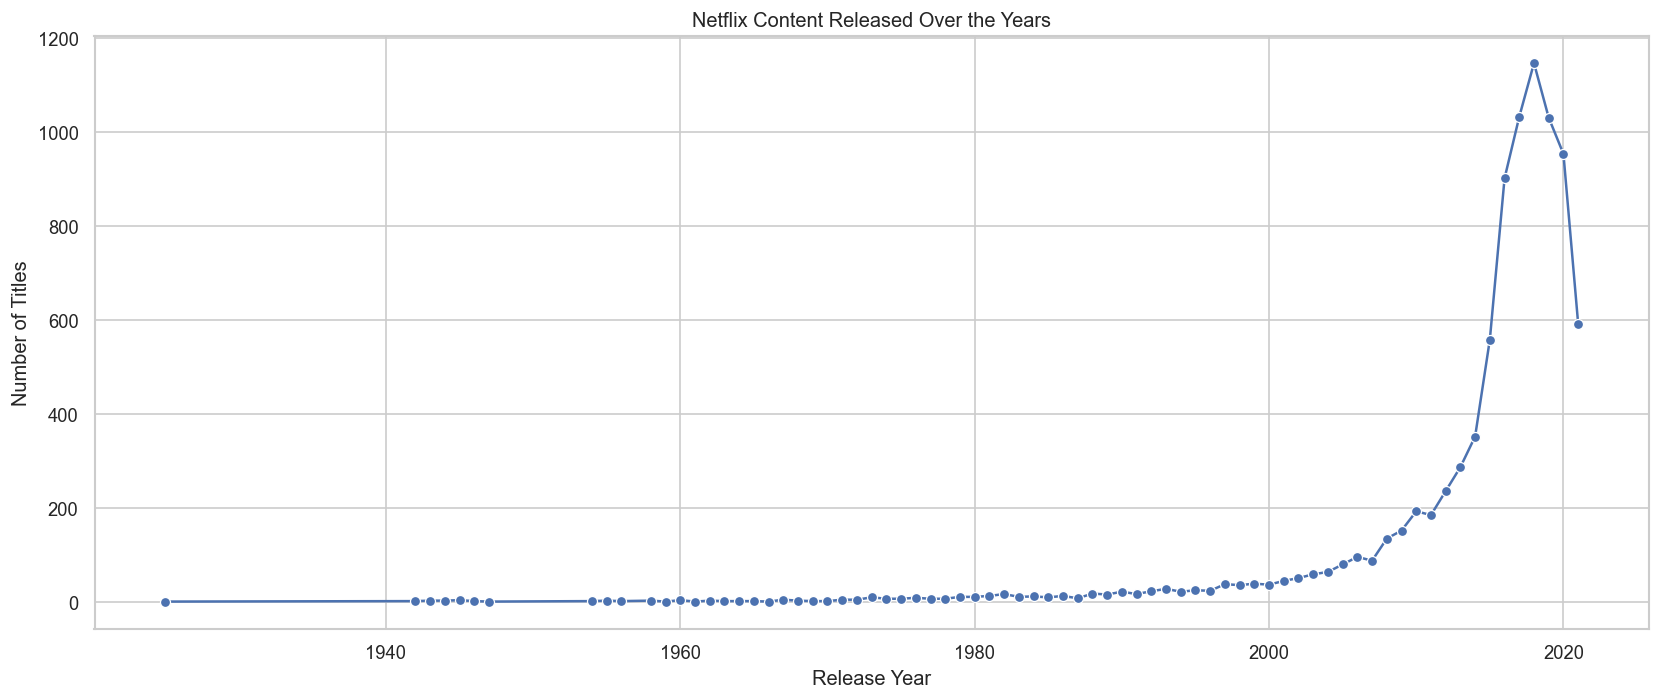

In [110]:
# Plot release trend

plt.figure(figsize=(14,6))

sns.lineplot(
    x=release_trend.index,
    y=release_trend.values,
    marker="o"
)

plt.title("Netflix Content Released Over the Years")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()

### Key Insight

The number of titles released has grown significantly over the last two decades, indicating Netflix's increasing investment in expanding its content library.

----------------------------------------------------------------------------------------------------------------------------------------------

## Movies and TV Shows by Country

### Objective

The objective of this analysis is to compare the distribution of Movies and TV Shows across the countries with the highest number of Netflix titles.

In [111]:
# Select top 10 countries

top_country_names = (
    netflix_df["primary_country"]
    .value_counts()
    .head(10)
    .index
)

country_type = netflix_df[
    netflix_df["primary_country"].isin(top_country_names)
]

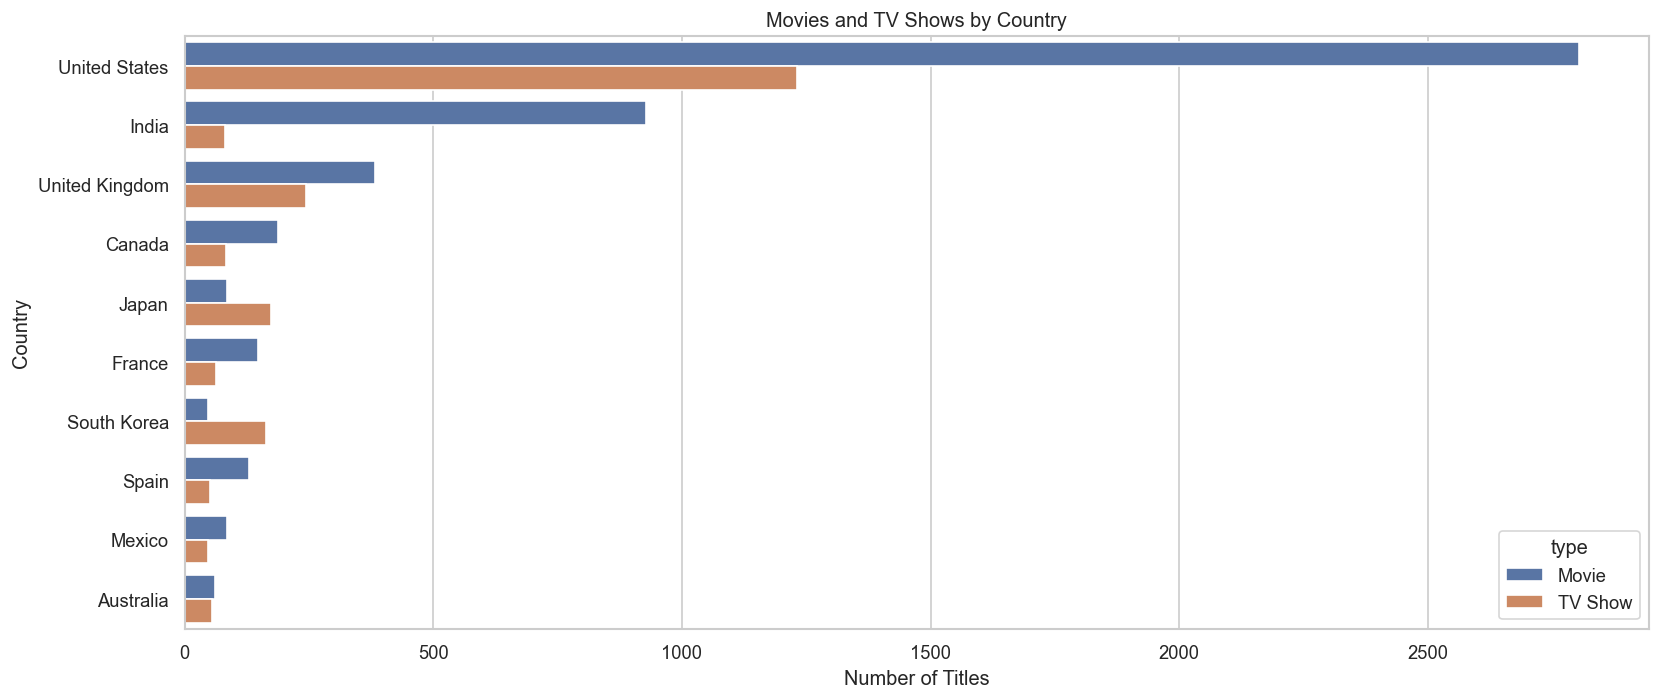

In [112]:
# Plot comparison

plt.figure(figsize=(14,6))

sns.countplot(
    data=country_type,
    y="primary_country",
    hue="type",
    order=top_country_names
)

plt.title("Movies and TV Shows by Country")

plt.xlabel("Number of Titles")

plt.ylabel("Country")

plt.tight_layout()

plt.show()

### Key Insight

Most of the leading countries contribute more Movies than TV Shows. However, the ratio varies across countries, highlighting differences in regional content production.

----------------------------------------------------------------------------------------------------------------------------------------------

## Content Composition

### Objective

The objective of this analysis is to visualize the proportion of Movies and TV Shows in the Netflix catalog.

In [113]:
# Calculate content distribution

content_counts = netflix_df["type"].value_counts()

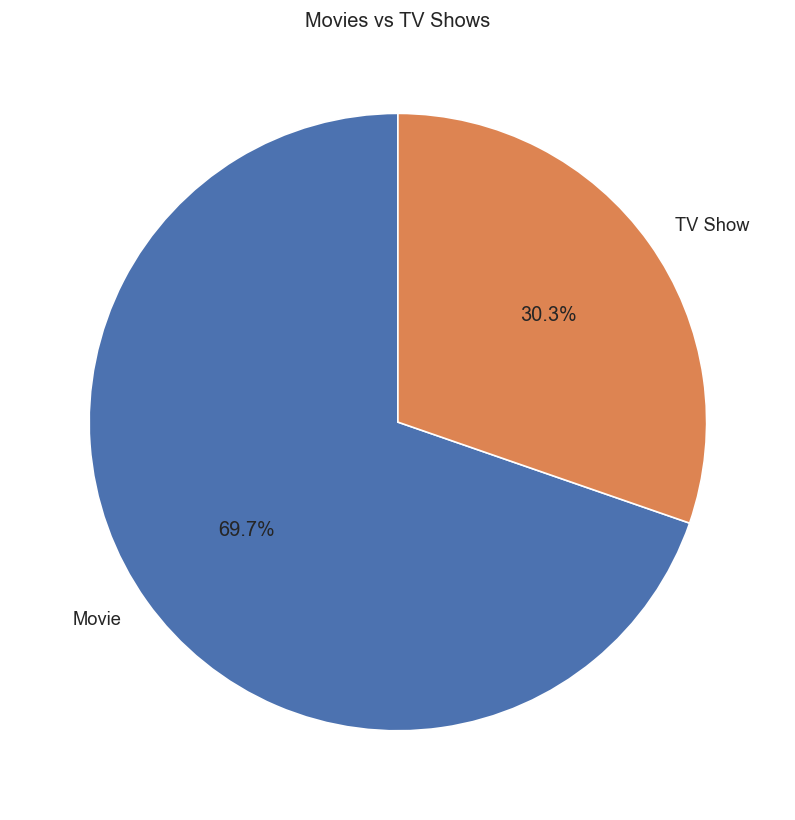

In [114]:
# Pie chart

plt.figure(figsize=(7,7))

plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.tight_layout()

plt.show()

### Key Insight

Movies make up the majority of Netflix's content library, while TV Shows represent a smaller but significant portion of the catalog.

----------------------------------------------------------------------------------------------------------------------------------------------

## Years with the Highest Number of Releases

### Objective

The objective of this analysis is to identify the years in which the largest number of Netflix titles were released.

In [115]:
# Top release years

top_release_years = (
    netflix_df["release_year"]
    .value_counts()
    .head(10)
)

print(top_release_years)

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
2021     592
2015     558
2014     352
2013     287
2012     236
Name: count, dtype: int64


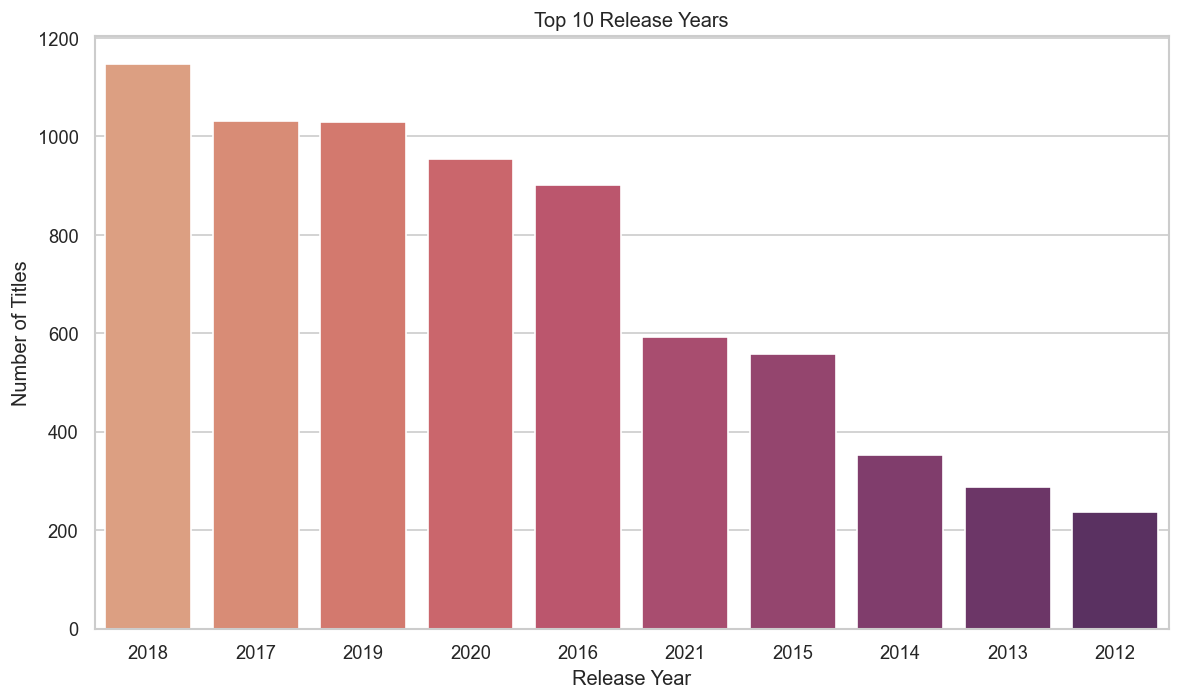

In [116]:
# Plot top release years

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_release_years.index.astype(str),
    y=top_release_years.values,
    hue=top_release_years.index.astype(str),
    palette="flare",
    legend=False
)

plt.title("Top 10 Release Years")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()

### Key Insight

The majority of Netflix titles belong to recent years, indicating that the platform focuses heavily on contemporary content.

----------------------------------------------------------------------------------------------------------------------------------------------

## Correlation Analysis

### Objective

The objective of this analysis is to examine relationships between the available numerical features in the dataset.

In [117]:
# Select numerical columns

numeric_columns = netflix_df.select_dtypes(include="number")

numeric_columns.head()

,release_year,year_added,movie_duration
0,2020,2021,90.0
1,2021,2021,2.0
2,2021,2021,1.0
3,2021,2021,1.0
4,2021,2021,2.0


In [118]:
# Correlation matrix

correlation_matrix = numeric_columns.corr()

correlation_matrix

,release_year,year_added,movie_duration
release_year,1.000000,0.111531,-0.249925
year_added,0.111531,1.000000,0.029345
movie_duration,-0.249925,0.029345,1.000000


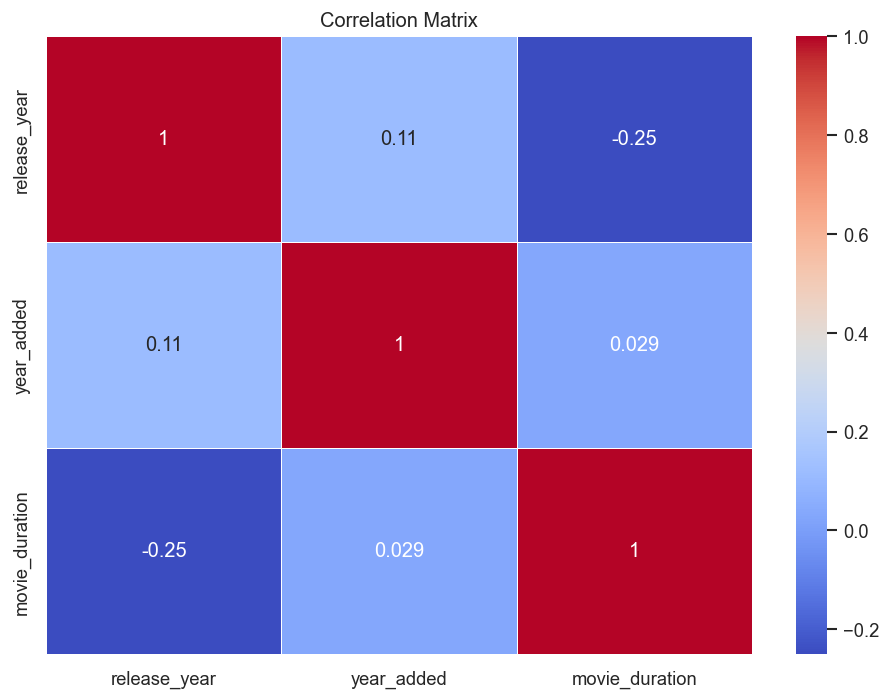

In [119]:
# Plot heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Key Insight

The numerical variables show only weak to moderate relationships. This suggests that most numerical features capture different aspects of the dataset rather than being strongly dependent on each other.

----------------------------------------------------------------------------------------------------------------------------------------------

## Content Added by Day

### Objective

The objective of this analysis is to identify whether Netflix tends to add more content on specific days of the week.

In [120]:
# Arrange weekdays

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_content = (
    netflix_df["day_added"]
    .value_counts()
    .reindex(day_order)
)

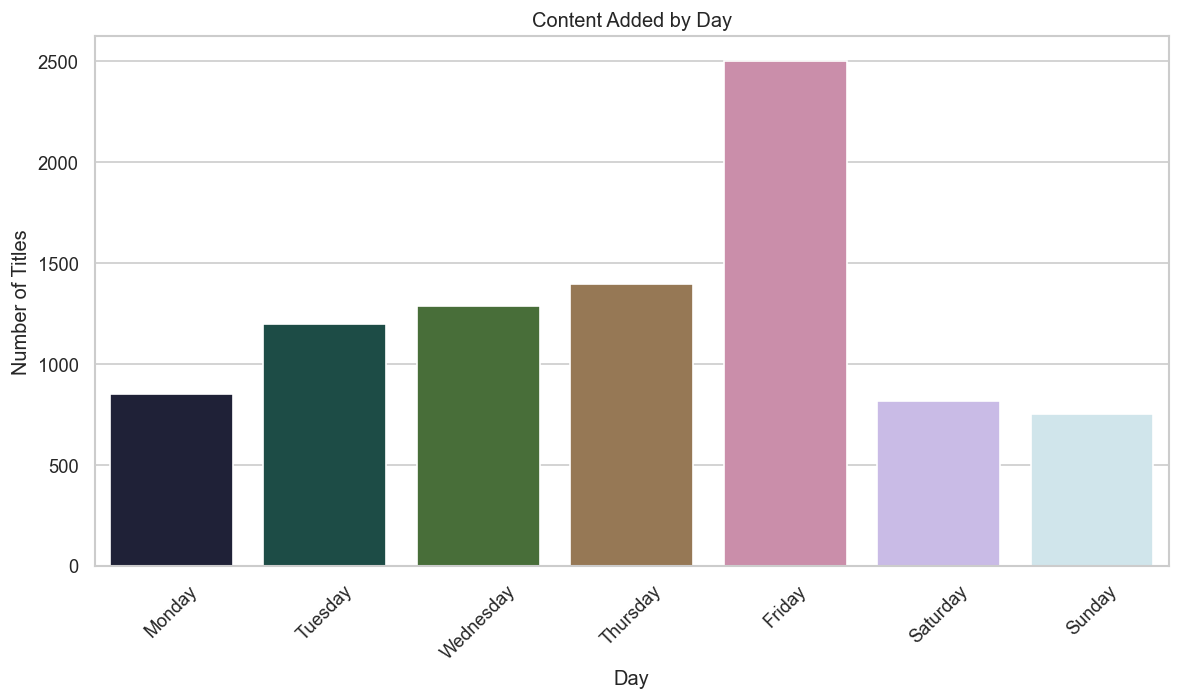

In [121]:
# Plot day-wise additions

plt.figure(figsize=(10,6))

sns.barplot(
    x=day_content.index,
    y=day_content.values,
    hue=day_content.index,
    palette="cubehelix",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Content Added by Day")

plt.xlabel("Day")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.show()

### Key Insight

Netflix adds content throughout the week, although some days experience noticeably higher activity than others. This may reflect scheduled content release strategies.

----------------------------------------------------------------------------------------------------------------------------------------------

# Business Insights

## Objective

The objective of this chapter is to interpret the findings obtained from the exploratory data analysis (EDA) and translate them into meaningful business insights. These insights provide a better understanding of Netflix's content strategy, audience preferences, and overall content distribution.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 1: Movies Dominate the Netflix Catalog

### Evidence

The "Movies vs TV Shows" analysis showed that Movies account for a significantly larger share of Netflix's content library.

### Business Impact

A larger movie catalog allows Netflix to attract a broader audience by providing quick-to-consume entertainment across multiple genres and languages.

### Recommendation

Netflix should continue investing in original movies while gradually increasing high-quality TV Shows to improve long-term user engagement and subscriber retention.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 2: Rapid Growth After 2015

### Evidence

The yearly content addition analysis showed a sharp increase in the number of titles added after 2015.

### Business Impact

This indicates Netflix's aggressive global expansion strategy and increased investment in licensed and original content during this period.

### Recommendation

Maintaining a consistent content acquisition strategy can help Netflix sustain subscriber growth and remain competitive in the streaming industry.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 3: Strong Presence of the United States

### Evidence

The country-wise analysis revealed that the United States contributes the highest number of titles available on Netflix.

### Business Impact

The U.S. remains Netflix's strongest content production market, supported by its well-established entertainment industry.

### Recommendation

Netflix should continue strengthening regional content production in emerging markets such as India, South Korea, and Latin America to diversify its global content library.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 4: Drama is the Most Popular Genre

### Evidence

The genre distribution analysis identified Drama as the most frequently occurring genre in the dataset.

### Business Impact

The popularity of Drama indicates strong audience demand for emotionally engaging and story-driven content.

### Recommendation

Netflix should continue investing in high-quality drama productions while balancing its catalog with other popular genres such as Comedy and Documentaries.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 5: Content Primarily Targets Mature Audiences

### Evidence

The rating distribution showed that TV-MA and TV-14 are the most common content ratings.

### Business Impact

Netflix primarily focuses on teenagers and adults, reflecting the viewing preferences of its largest subscriber segments.

### Recommendation

Increasing the availability of family-friendly and children's content may help expand Netflix's audience base.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 6: Standard Movie Runtime

### Evidence

The movie duration analysis revealed that most movies have a runtime between 80 and 120 minutes.

### Business Impact

This duration aligns with audience expectations for feature-length films and supports better viewer engagement.

### Recommendation

Future productions should generally maintain this duration range while allowing flexibility for content that benefits from longer runtimes.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 7: Diverse Content Creators

### Evidence

The director analysis showed that only a small number of directors contribute multiple titles, while most appear only once.

### Business Impact

Netflix collaborates with a wide range of filmmakers, encouraging diversity in storytelling and creative perspectives.

### Recommendation

Continuing partnerships with both established and emerging directors can further strengthen the platform's content diversity.

----------------------------------------------------------------------------------------------------------------------------------------------

## Business Insight 8: Focus on Recent Content

### Evidence

The release year analysis indicates that a large proportion of Netflix titles were released within the last decade.

### Business Impact

Modern content helps Netflix remain relevant and meet changing audience preferences.

### Recommendation

Netflix should maintain a balanced mix of newly released content and classic titles to satisfy different viewer preferences.

----------------------------------------------------------------------------------------------------------------------------------------------

## Overall Business Summary

The analysis indicates that Netflix has successfully expanded its global content library through continuous investment in Movies, regional content production, and diverse genres. The platform primarily targets mature audiences while maintaining a strong presence in major entertainment markets such as the United States and India.

The insights generated from this analysis can help support strategic decisions related to content acquisition, genre investment, audience targeting, and international expansion.

----------------------------------------------------------------------------------------------------------------------------------------------

# Final Dashboard

## Objective

The objective of this dashboard is to present the most important insights from the Netflix dataset in a single view. It summarizes key metrics and visualizations, enabling quick understanding of Netflix's content distribution and trends.

In [122]:
# Calculate important business metrics

total_titles = len(netflix_df)

total_movies = netflix_df[netflix_df["type"] == "Movie"].shape[0]

total_tvshows = netflix_df[netflix_df["type"] == "TV Show"].shape[0]

total_countries = netflix_df["primary_country"].nunique()

total_genres = netflix_df["primary_genre"].nunique()

print("Netflix Dashboard Metrics")
print("-" * 40)

print(f"Total Titles     : {total_titles}")
print(f"Movies           : {total_movies}")
print(f"TV Shows         : {total_tvshows}")
print(f"Countries        : {total_countries}")
print(f"Genres           : {total_genres}")

Netflix Dashboard Metrics
----------------------------------------
Total Titles     : 8797
Movies           : 6131
TV Shows         : 2666
Countries        : 86
Genres           : 36


### Key Insights

The dashboard metrics provide a quick overview of the Netflix dataset. These key performance indicators (KPIs) summarize the size and diversity of the content library before moving to the visual dashboard.

----------------------------------------------------------------------------------------------------------------------------------------------

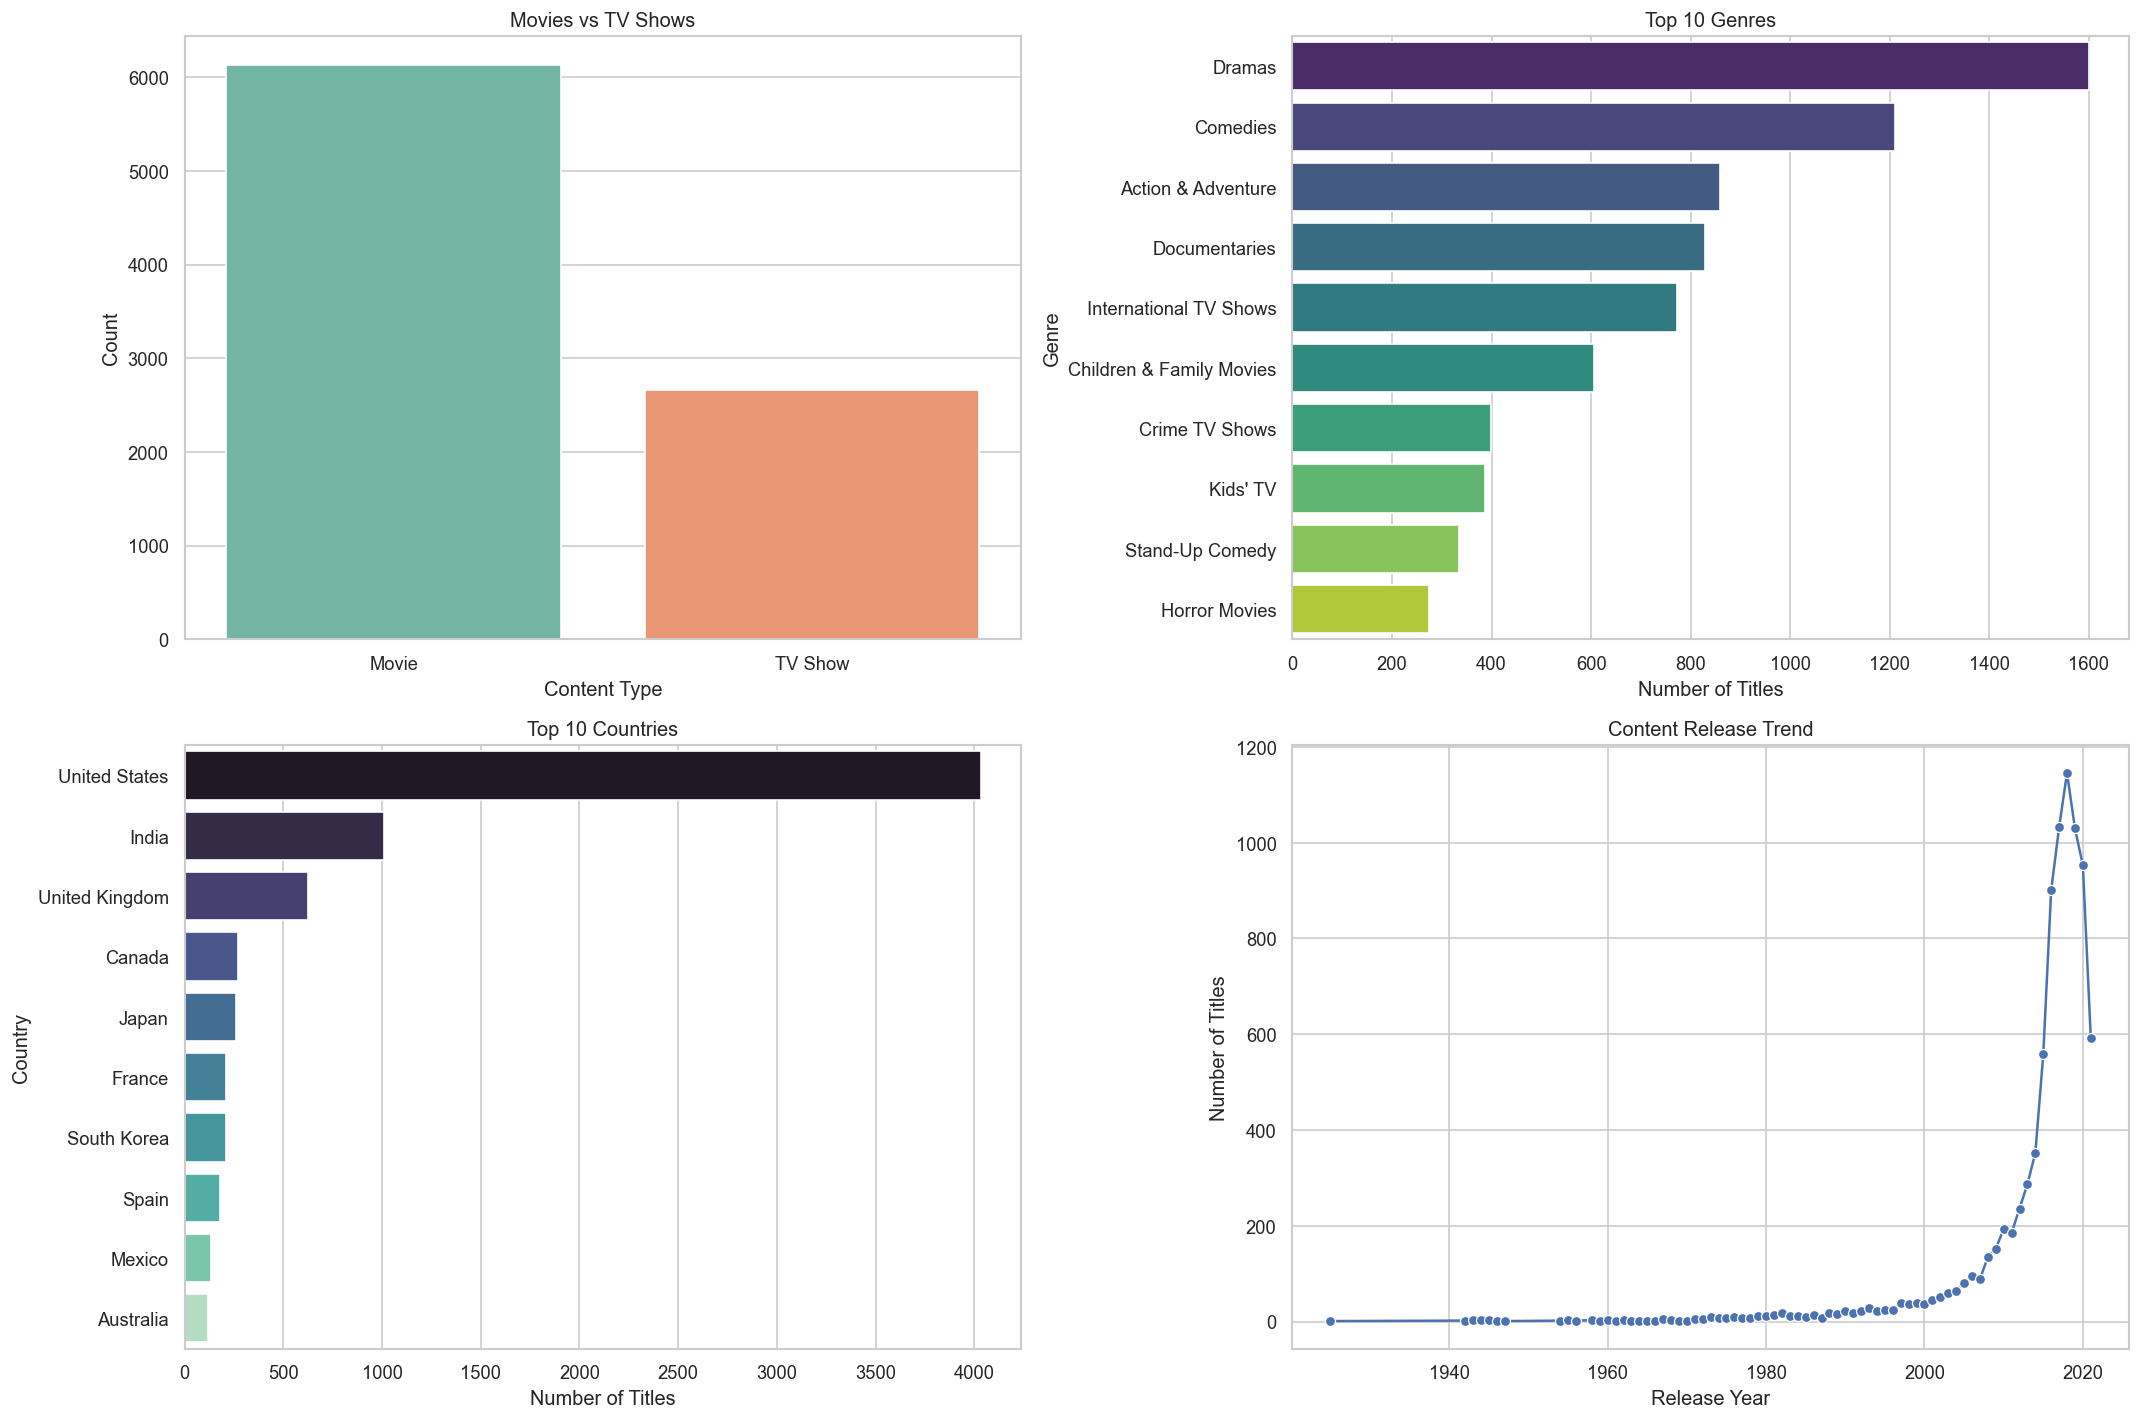

Dashboard created and saved successfully as 'dashboard.png'.


In [127]:
# Create a dashboard containing the most important visualizations

plt.figure(figsize=(18,12))

# -----------------------
# Movies vs TV Shows
# -----------------------

plt.subplot(2,2,1)

sns.countplot(
    data=netflix_df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Movies vs TV Shows")

plt.xlabel("Content Type")

plt.ylabel("Count")


# -----------------------
# Top Genres
# -----------------------

plt.subplot(2,2,2)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Genres")

plt.xlabel("Number of Titles")

plt.ylabel("Genre")


# -----------------------
# Top Countries
# -----------------------

plt.subplot(2,2,3)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette="mako",
    legend=False
)

plt.title("Top 10 Countries")

plt.xlabel("Number of Titles")

plt.ylabel("Country")


# -----------------------
# Content Release Trend
# -----------------------

plt.subplot(2,2,4)

sns.lineplot(
    x=release_trend.index,
    y=release_trend.values,
    marker="o"
)

plt.title("Content Release Trend")

plt.xlabel("Release Year")

plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig(
    "dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Dashboard created and saved successfully as 'dashboard.png'.")

### Key Insights

The dashboard combines the most important findings into a single view. It provides a quick summary of Netflix's content composition, genre distribution, geographic contribution, and release trends, making it easier to communicate insights to stakeholders.

----------------------------------------------------------------------------------------------------------------------------------------------

# Conclusion & Export

## Objective

The objective of this chapter is to summarize the entire analysis, highlight the key outcomes of the project, and export the cleaned dataset for future use.

In [128]:
# Save the cleaned dataset as a CSV file

import os

os.makedirs("cleaned_data", exist_ok=True)

netflix_df.to_csv(
    "cleaned_data/cleaned_netflix.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


### Key Insights

The cleaned and processed dataset has been successfully exported. This dataset can now be used for future analysis, dashboard development, or machine learning tasks without repeating the preprocessing steps.

----------------------------------------------------------------------------------------------------------------------------------------------

## Project Summary

This project focused on cleaning, preprocessing, analyzing, and visualizing the Netflix Movies and TV Shows dataset using Python.

The workflow included handling missing values, checking duplicate records, converting data types, creating new features, and performing exploratory data analysis (EDA). Multiple visualizations were developed to uncover trends in content distribution, genre popularity, country-wise production, release patterns, and audience ratings.

Finally, a dashboard was created to summarize the most important findings, providing a concise and visually informative overview of the dataset.

----------------------------------------------------------------------------------------------------------------------------------------------

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

----------------------------------------------------------------------------------------------------------------------------------------------

## Skills Demonstrated

- Data Cleaning
- Data Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation
- Dashboard Development
- Data Storytelling

----------------------------------------------------------------------------------------------------------------------------------------------

## Future Scope

This project can be further enhanced by integrating interactive dashboards using Power BI or Tableau. Predictive models can also be developed to analyze future content trends, genre popularity, and audience preferences. Additionally, recommendation systems can be implemented using machine learning techniques to provide personalized content suggestions.

----------------------------------------------------------------------------------------------------------------------------------------------

## Conclusion

The Netflix Data Cleaning and Visualization project successfully demonstrated the complete data analysis workflow, from raw data preprocessing to business insight generation.

The analysis revealed that Netflix's catalog is dominated by movies, with strong contributions from countries such as the United States and India. Drama emerged as the most common genre, while TV-MA and TV-14 were the dominant content ratings. The dashboard and visualizations effectively summarized these findings and provided a clear understanding of Netflix's content strategy.

Overall, this project strengthened practical skills in data cleaning, feature engineering, visualization, and data storytelling using Python and its data analysis libraries.

----------------------------------------------------------------------------------------------------------------------------------------------